In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
DATA_PATH = Path("../output/progressive_hypoxemia.csv")

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["event_time"],
)

df.head()


,event_time,sequence_number,heart_rate_bpm,spo2_pct,respiration_rate_bpm,temperature_c,systolic_bp_mmhg,diastolic_bp_mmhg
0,2026-01-01 00:00:05+00:00,1,71.949568,97.991355,13.986642,36.807020,119.942585,75.550794
1,2026-01-01 00:00:10+00:00,2,72.068920,97.978680,13.961720,36.807968,120.049990,75.922322
2,2026-01-01 00:00:15+00:00,3,72.296576,97.985911,13.876186,36.797582,120.158344,76.319530
3,2026-01-01 00:00:20+00:00,4,72.297173,97.981722,13.947935,36.783119,120.009902,76.450662
4,2026-01-01 00:00:25+00:00,5,72.589102,97.971152,13.996909,36.786108,120.361454,76.094163


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   event_time            4320 non-null   datetime64[us, UTC]
 1   sequence_number       4320 non-null   int64              
 2   heart_rate_bpm        4320 non-null   float64            
 3   spo2_pct              4320 non-null   float64            
 4   respiration_rate_bpm  4320 non-null   float64            
 5   temperature_c         4320 non-null   float64            
 6   systolic_bp_mmhg      4320 non-null   float64            
 7   diastolic_bp_mmhg     4320 non-null   float64            
dtypes: datetime64[us, UTC](1), float64(6), int64(1)
memory usage: 270.1 KB


In [5]:
df.shape


(4320, 8)

In [6]:
df["event_time"].min(), df["event_time"].max()

(Timestamp('2026-01-01 00:00:05+0000', tz='UTC'),
 Timestamp('2026-01-01 06:00:00+0000', tz='UTC'))

In [7]:
df["event_time"].is_monotonic_increasing

True

In [8]:
df["time_delta"] = df["event_time"].diff()

df["time_delta"].value_counts()

time_delta
0 days 00:00:05    4319
Name: count, dtype: int64

In [9]:
df["time_delta"].describe()

count               4319
mean     0 days 00:00:05
std      0 days 00:00:00
min      0 days 00:00:05
25%      0 days 00:00:05
50%      0 days 00:00:05
75%      0 days 00:00:05
max      0 days 00:00:05
Name: time_delta, dtype: object

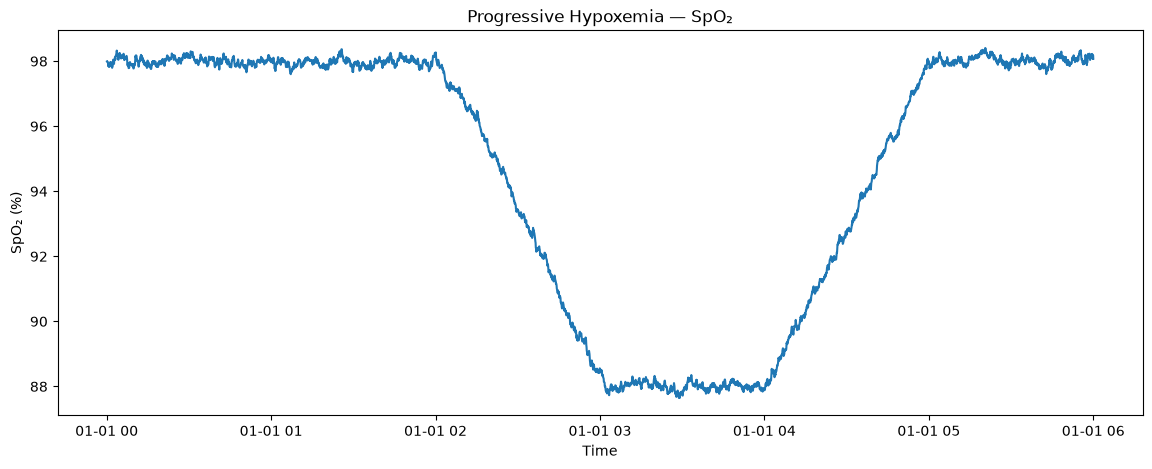

In [12]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["event_time"],
    df["spo2_pct"],
)

plt.xlabel("Time")
plt.ylabel("SpO₂ (%)")
plt.title("Progressive Hypoxemia — SpO₂")

plt.show()

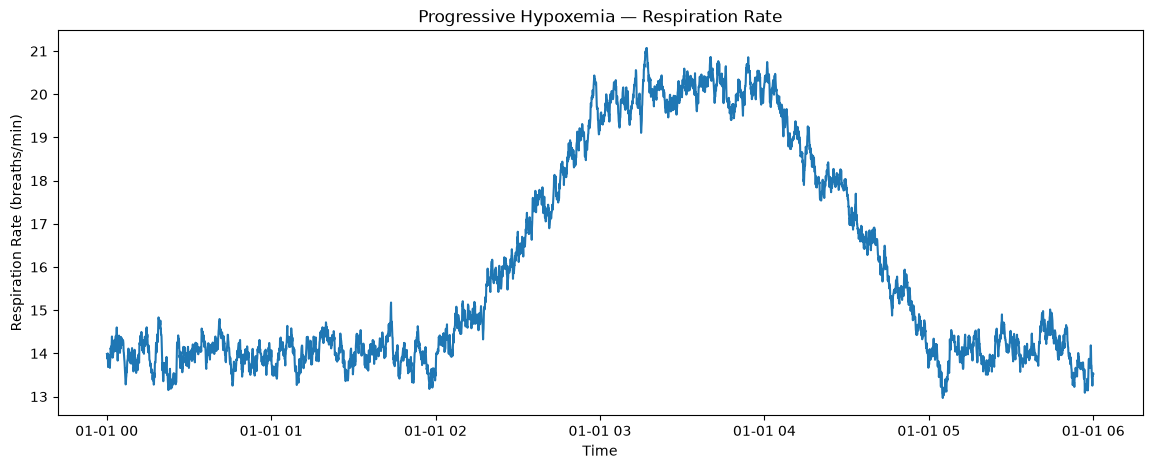

In [13]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["event_time"],
    df["respiration_rate_bpm"],
)

plt.xlabel("Time")
plt.ylabel("Respiration Rate (breaths/min)")
plt.title("Progressive Hypoxemia — Respiration Rate")

plt.show()


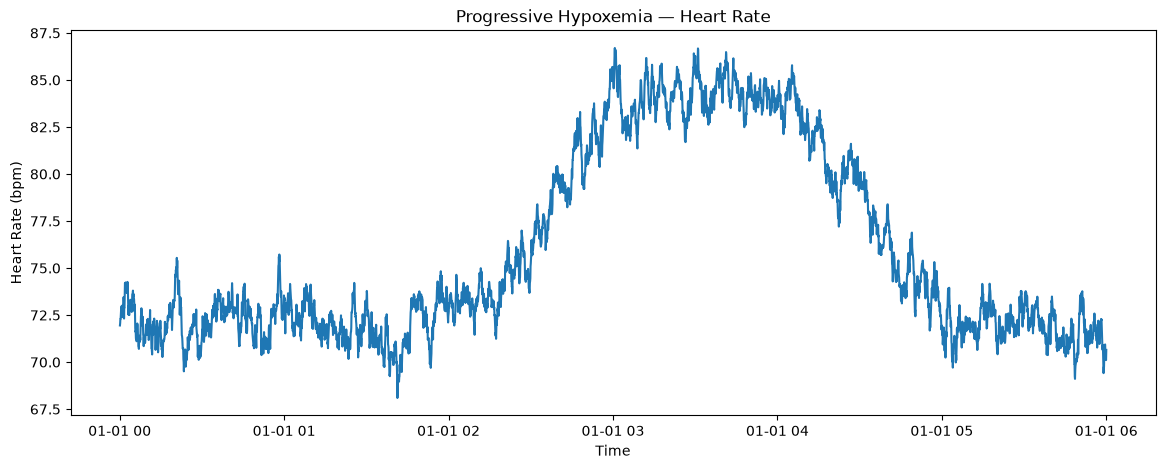

In [11]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["event_time"],
    df["heart_rate_bpm"],
)

plt.xlabel("Time")
plt.ylabel("Heart Rate (bpm)")
plt.title("Progressive Hypoxemia — Heart Rate")

plt.show()


In [15]:
WINDOW = 12

df["spo2_1min_avg"] = (
    df["spo2_pct"]
    .rolling(WINDOW)
    .mean()
)

df["hr_1min_avg"] = (
    df["heart_rate_bpm"]
    .rolling(WINDOW)
    .mean()
)

df["rr_1min_avg"] = (
    df["respiration_rate_bpm"]
    .rolling(WINDOW)
    .mean()
)

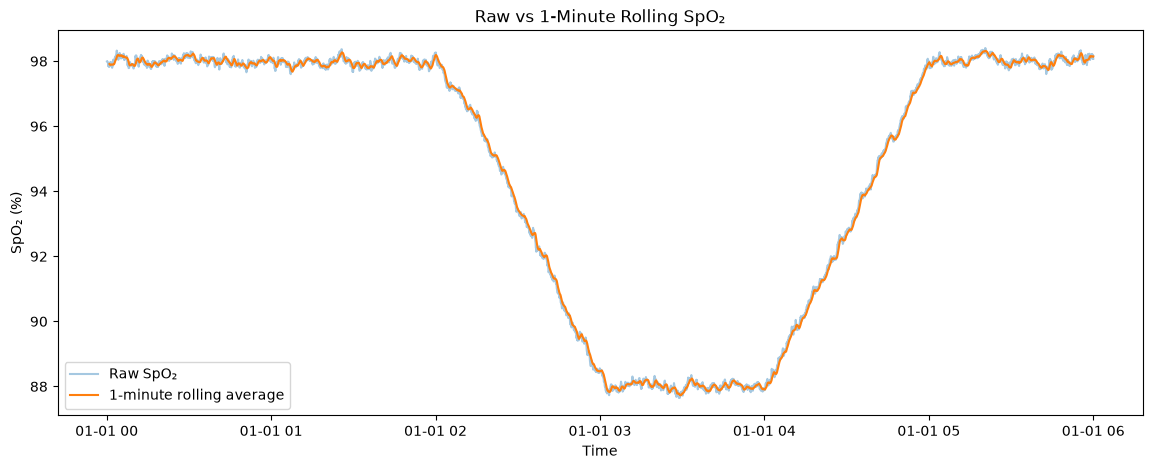

In [16]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["event_time"],
    df["spo2_pct"],
    alpha=0.4,
    label="Raw SpO₂",
)

plt.plot(
    df["event_time"],
    df["spo2_1min_avg"],
    label="1-minute rolling average",
)

plt.xlabel("Time")
plt.ylabel("SpO₂ (%)")
plt.title("Raw vs 1-Minute Rolling SpO₂")
plt.legend()

plt.show()


In [21]:
df["spo2_delta"] = df["spo2_pct"].diff()

In [22]:
df.columns

Index(['event_time', 'sequence_number', 'heart_rate_bpm', 'spo2_pct',
       'respiration_rate_bpm', 'temperature_c', 'systolic_bp_mmhg',
       'diastolic_bp_mmhg', 'time_delta', 'spo2_1min_avg', 'hr_1min_avg',
       'rr_1min_avg', 'spo2_delta'],
      dtype='str')

In [23]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["event_time"],
    df["spo2_change_1min"],
)

plt.axhline(
    0,
    linestyle="--",
)

plt.xlabel("Time")
plt.ylabel("SpO₂ Change Over 1 Minute")
plt.title("1-Minute SpO₂ Rate of Change")

plt.show()

KeyError: 'spo2_change_1min'

<Figure size 1400x500 with 0 Axes>

In [24]:
print(df.columns.tolist())

['event_time', 'sequence_number', 'heart_rate_bpm', 'spo2_pct', 'respiration_rate_bpm', 'temperature_c', 'systolic_bp_mmhg', 'diastolic_bp_mmhg', 'time_delta', 'spo2_1min_avg', 'hr_1min_avg', 'rr_1min_avg', 'spo2_delta']


In [25]:
df["spo2_change_1min"] = df["spo2_pct"].diff(12)

print("created:", "spo2_change_1min" in df.columns)
print(df[["spo2_pct", "spo2_change_1min"]].head(15))

created: True
     spo2_pct  spo2_change_1min
0   97.991355               NaN
1   97.978680               NaN
2   97.985911               NaN
3   97.981722               NaN
4   97.971152               NaN
5   97.897734               NaN
6   97.844962               NaN
7   97.898297               NaN
8   97.870564               NaN
9   97.825975               NaN
10  97.835196               NaN
11  97.861042               NaN
12  97.841689         -0.149666
13  97.891819         -0.086861
14  97.921261         -0.064649


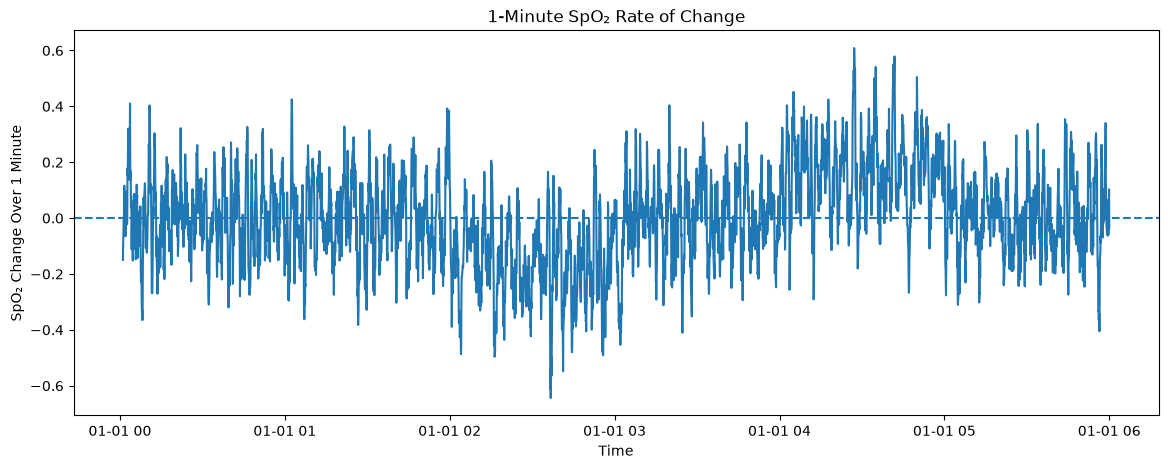

In [26]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["event_time"],
    df["spo2_change_1min"],
)

plt.axhline(0, linestyle="--")

plt.xlabel("Time")
plt.ylabel("SpO₂ Change Over 1 Minute")
plt.title("1-Minute SpO₂ Rate of Change")

plt.show()

In [27]:
below_94 = df[
    df["spo2_pct"] < 94
]

below_94.head()

,event_time,sequence_number,heart_rate_bpm,spo2_pct,respiration_rate_bpm,temperature_c,systolic_bp_mmhg,diastolic_bp_mmhg,time_delta,spo2_1min_avg,hr_1min_avg,rr_1min_avg,spo2_delta,spo2_change_1min
1770,2026-01-01 02:27:35+00:00,1771,75.894299,93.979300,15.998695,36.756812,120.713486,77.607346,0 days 00:00:05,94.116738,76.232921,16.010064,-0.115474,-0.156846
1771,2026-01-01 02:27:40+00:00,1772,75.833304,93.902703,16.261178,36.733751,120.862667,77.596182,0 days 00:00:05,94.095700,76.136071,16.036105,-0.076598,-0.252455
1772,2026-01-01 02:27:45+00:00,1773,75.780983,93.843066,16.276097,36.729797,120.816378,77.335508,0 days 00:00:05,94.072784,76.049686,16.063171,-0.059637,-0.274998
1773,2026-01-01 02:27:50+00:00,1774,74.976774,93.884170,16.411484,36.734456,121.163192,77.743894,0 days 00:00:05,94.051364,75.906773,16.101800,0.041104,-0.257044
1774,2026-01-01 02:27:55+00:00,1775,74.494825,93.876415,16.299055,36.733478,120.965701,77.963769,0 days 00:00:05,94.024966,75.727768,16.137388,-0.007755,-0.316777


In [28]:
first_below_94 = below_94.iloc[0]

first_below_94[
    [
        "event_time",
        "spo2_pct",
        "heart_rate_bpm",
        "respiration_rate_bpm",
    ]
]

event_time              2026-01-01 02:27:35+00:00
spo2_pct                                  93.9793
heart_rate_bpm                          75.894299
respiration_rate_bpm                    15.998695
Name: 1770, dtype: object

In [29]:
df["spo2_below_94"] = df["spo2_pct"] < 94

below_count = df["spo2_below_94"].sum()

duration_seconds = below_count * 5
duration_minutes = duration_seconds / 60

print("Observations below 94%:", below_count)
print("Duration below 94%:", duration_minutes, "minutes")

Observations below 94%: 1555
Duration below 94%: 129.58333333333334 minutes


In [30]:
df[
    [
        "spo2_pct",
        "heart_rate_bpm",
        "respiration_rate_bpm",
    ]
].corr()

,spo2_pct,heart_rate_bpm,respiration_rate_bpm
spo2_pct,1.000000,-0.975994,-0.989764
heart_rate_bpm,-0.975994,1.000000,0.971564
respiration_rate_bpm,-0.989764,0.971564,1.000000


In [31]:
baseline_spo2 = df.loc[
    df["event_time"] < pd.Timestamp(
        "2026-01-01 02:00:00+00:00"
    ),
    "spo2_pct",
].mean()

baseline_spo2

np.float64(97.98185439340371)

In [33]:
df["oxygen_deficit"] = (
    baseline_spo2 - df["spo2_pct"]
)

In [34]:
df[
    [
        "event_time",
        "spo2_pct",
        "oxygen_deficit",
    ]
].iloc[1430:1460]

,event_time,spo2_pct,oxygen_deficit
1430,2026-01-01 01:59:15+00:00,98.131395,-0.149541
1431,2026-01-01 01:59:20+00:00,98.144413,-0.162559
1432,2026-01-01 01:59:25+00:00,98.128410,-0.146556
1433,2026-01-01 01:59:30+00:00,98.139750,-0.157895
1434,2026-01-01 01:59:35+00:00,98.183479,-0.201624
1435,2026-01-01 01:59:40+00:00,98.201003,-0.219149
1436,2026-01-01 01:59:45+00:00,98.256670,-0.274816
1437,2026-01-01 01:59:50+00:00,98.208328,-0.226474
1438,2026-01-01 01:59:55+00:00,98.237261,-0.255407
1439,2026-01-01 02:00:00+00:00,98.209380,-0.227525
